### 데이터 뽑아오기

In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. 티커 매핑
# =========================================
tickers = {
    'KOSPI 200': '^KS200',          # 기준 자산
    'USD/KRW': 'KRW=X',
    'USD/CNY': 'CNY=X',
    'JPY/KRW': 'JPYKRW=X',
    'Gold Spot': 'GC=F',
    'TOPIX': '1306.T',
    'Shanghai Comp': '000001.SS',
    'KODEX 200': '069500.KS',
    'KOSDAQ': '^KQ11',
    'Brent Crude Oil': 'BZ=F',
    'NASDAQ': '^IXIC'               # 추가
}

# =========================================
# 2. 야후 파이낸스 데이터 다운로드
# =========================================
price_data = yf.download(
    list(tickers.values()),
    start='2008-01-01',
    end='2026-03-01',
    auto_adjust=False,
    progress=False
)

# ticker -> 자산명 역매핑
name_mapping = {v: k for k, v in tickers.items()}

# =========================================
# 3. Close 데이터만 먼저 정리
#    (파생변수는 전부 Close 기준으로 만들 예정)
# =========================================
close_data = price_data['Close'].rename(columns=name_mapping)

# KOSPI 200 Close만 남기고,
# 기존의 중복 변수명 'KOSPI 200'은 제거하기 위해 이름 변경
close_data = close_data.rename(columns={'KOSPI 200': 'KOSPI 200 Close'})

# =========================================
# 4. KOSPI 200의 OHLC 추가
# =========================================
kospi_ticker = tickers['KOSPI 200']

ohlc_data = pd.DataFrame(index=price_data.index)
ohlc_data['KOSPI 200 Open'] = price_data['Open'][kospi_ticker]
ohlc_data['KOSPI 200 High'] = price_data['High'][kospi_ticker]
ohlc_data['KOSPI 200 Low'] = price_data['Low'][kospi_ticker]
# Close는 이미 있으므로 여기서 따로 또 만들지 않음

# =========================================
# 5. Close 데이터 + OHLC 결합
# =========================================
data = pd.concat([close_data, ohlc_data], axis=1)

# =========================================
# 6. KRW/CNY 교차환율 계산
#    KRW/CNY = KRW/USD ÷ USD/CNY
# =========================================
data['CNY/KRW'] = data['USD/KRW'] / data['USD/CNY']

# =========================================
# 7. KOSPI 200 영업일 기준으로 정렬
#    기준 인덱스: KOSPI 200 Close가 존재하는 날짜
# =========================================
reference_index = data['KOSPI 200 Close'].dropna().index
data = data.reindex(reference_index).sort_index()

# 앞의 결측은 그대로 두고, 중간 결측은 forward fill
data = data.ffill()

# =========================================
# 8. 2008 전체 데이터 백업
#    (파생변수 계산용 원본)
# =========================================
data_2008 = data.copy()

# =========================================
# 9. 분석 시작일 이후 데이터
#    data_2009는 결측 없이 사용 가능하게 처리
# =========================================
data_2009 = data.loc['2009-04-17':].copy()

In [26]:
data_2008.head()

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,CNY/KRW
Date,,,,,,,,,,,,,,,
2008-01-02,5272.813965,NaN,NaN,97.839996,7.2852,857.000000,8.5750,937.119995,2609.629883,707.119995,235.300003,240.470001,240.649994,235.020004,128.633391
2008-01-03,5319.860840,NaN,NaN,97.599998,7.2629,866.400024,8.5379,935.150024,2602.679932,714.000000,234.669998,232.940002,235.639999,230.860001,128.757114
2008-01-04,5361.574219,NaN,1431.040039,96.790001,7.2630,863.099976,8.6477,939.530029,2504.649902,719.250000,235.770004,234.619995,236.589996,230.410004,129.358396
2008-01-07,5393.342773,NaN,1411.410034,94.389999,7.2578,859.599976,8.5970,939.270020,2499.459961,711.770020,231.000000,229.389999,232.419998,229.089996,129.415251
2008-01-08,5386.530762,NaN,1421.959961,95.540001,7.2535,878.000000,8.6145,938.890015,2440.510010,709.309998,230.339996,231.750000,232.320007,229.190002,129.439583


In [27]:
data_2009.head()

,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,CNY/KRW
Date,,,,,,,,,,,,,,,
2009-04-17,2503.935059,17370.0,875.0,51.959999,6.8226,867.400024,13.371,1325.800049,1673.069946,483.799988,171.330002,174.029999,174.990005,169.710007,194.324755
2009-04-20,2557.456055,17480.0,876.0,51.959999,6.8230,887.000000,13.536,1327.500000,1608.209961,491.940002,172.300003,172.550003,173.039993,169.039993,194.562510
2009-04-21,2535.827881,17480.0,855.0,51.959999,6.8169,882.099976,13.727,1354.300049,1643.849976,497.190002,171.960007,168.580002,172.350006,167.660004,198.668030
2009-04-22,2461.345947,17715.0,856.0,51.959999,6.8195,891.799988,13.726,1346.599976,1646.119995,509.899994,174.399994,173.279999,175.110001,171.860001,197.463154
2009-04-23,2463.954102,17895.0,862.0,51.959999,6.8193,905.900024,13.618,1333.599976,1652.209961,514.090027,176.139999,175.880005,176.639999,173.899994,195.562586


In [28]:
#data_8을 csv파일로 저장하는 코드
data_2008.to_csv(r'..\..\data\raw\data_2008.csv', index=True,encoding="utf-8-sig") # 2008년부터 데이터
data_2009.to_csv(r'..\..\data\raw\data_2009.csv', index=True,encoding="utf-8-sig") # 2009년 4월 17일부터 데이터


### 데이터 시각화

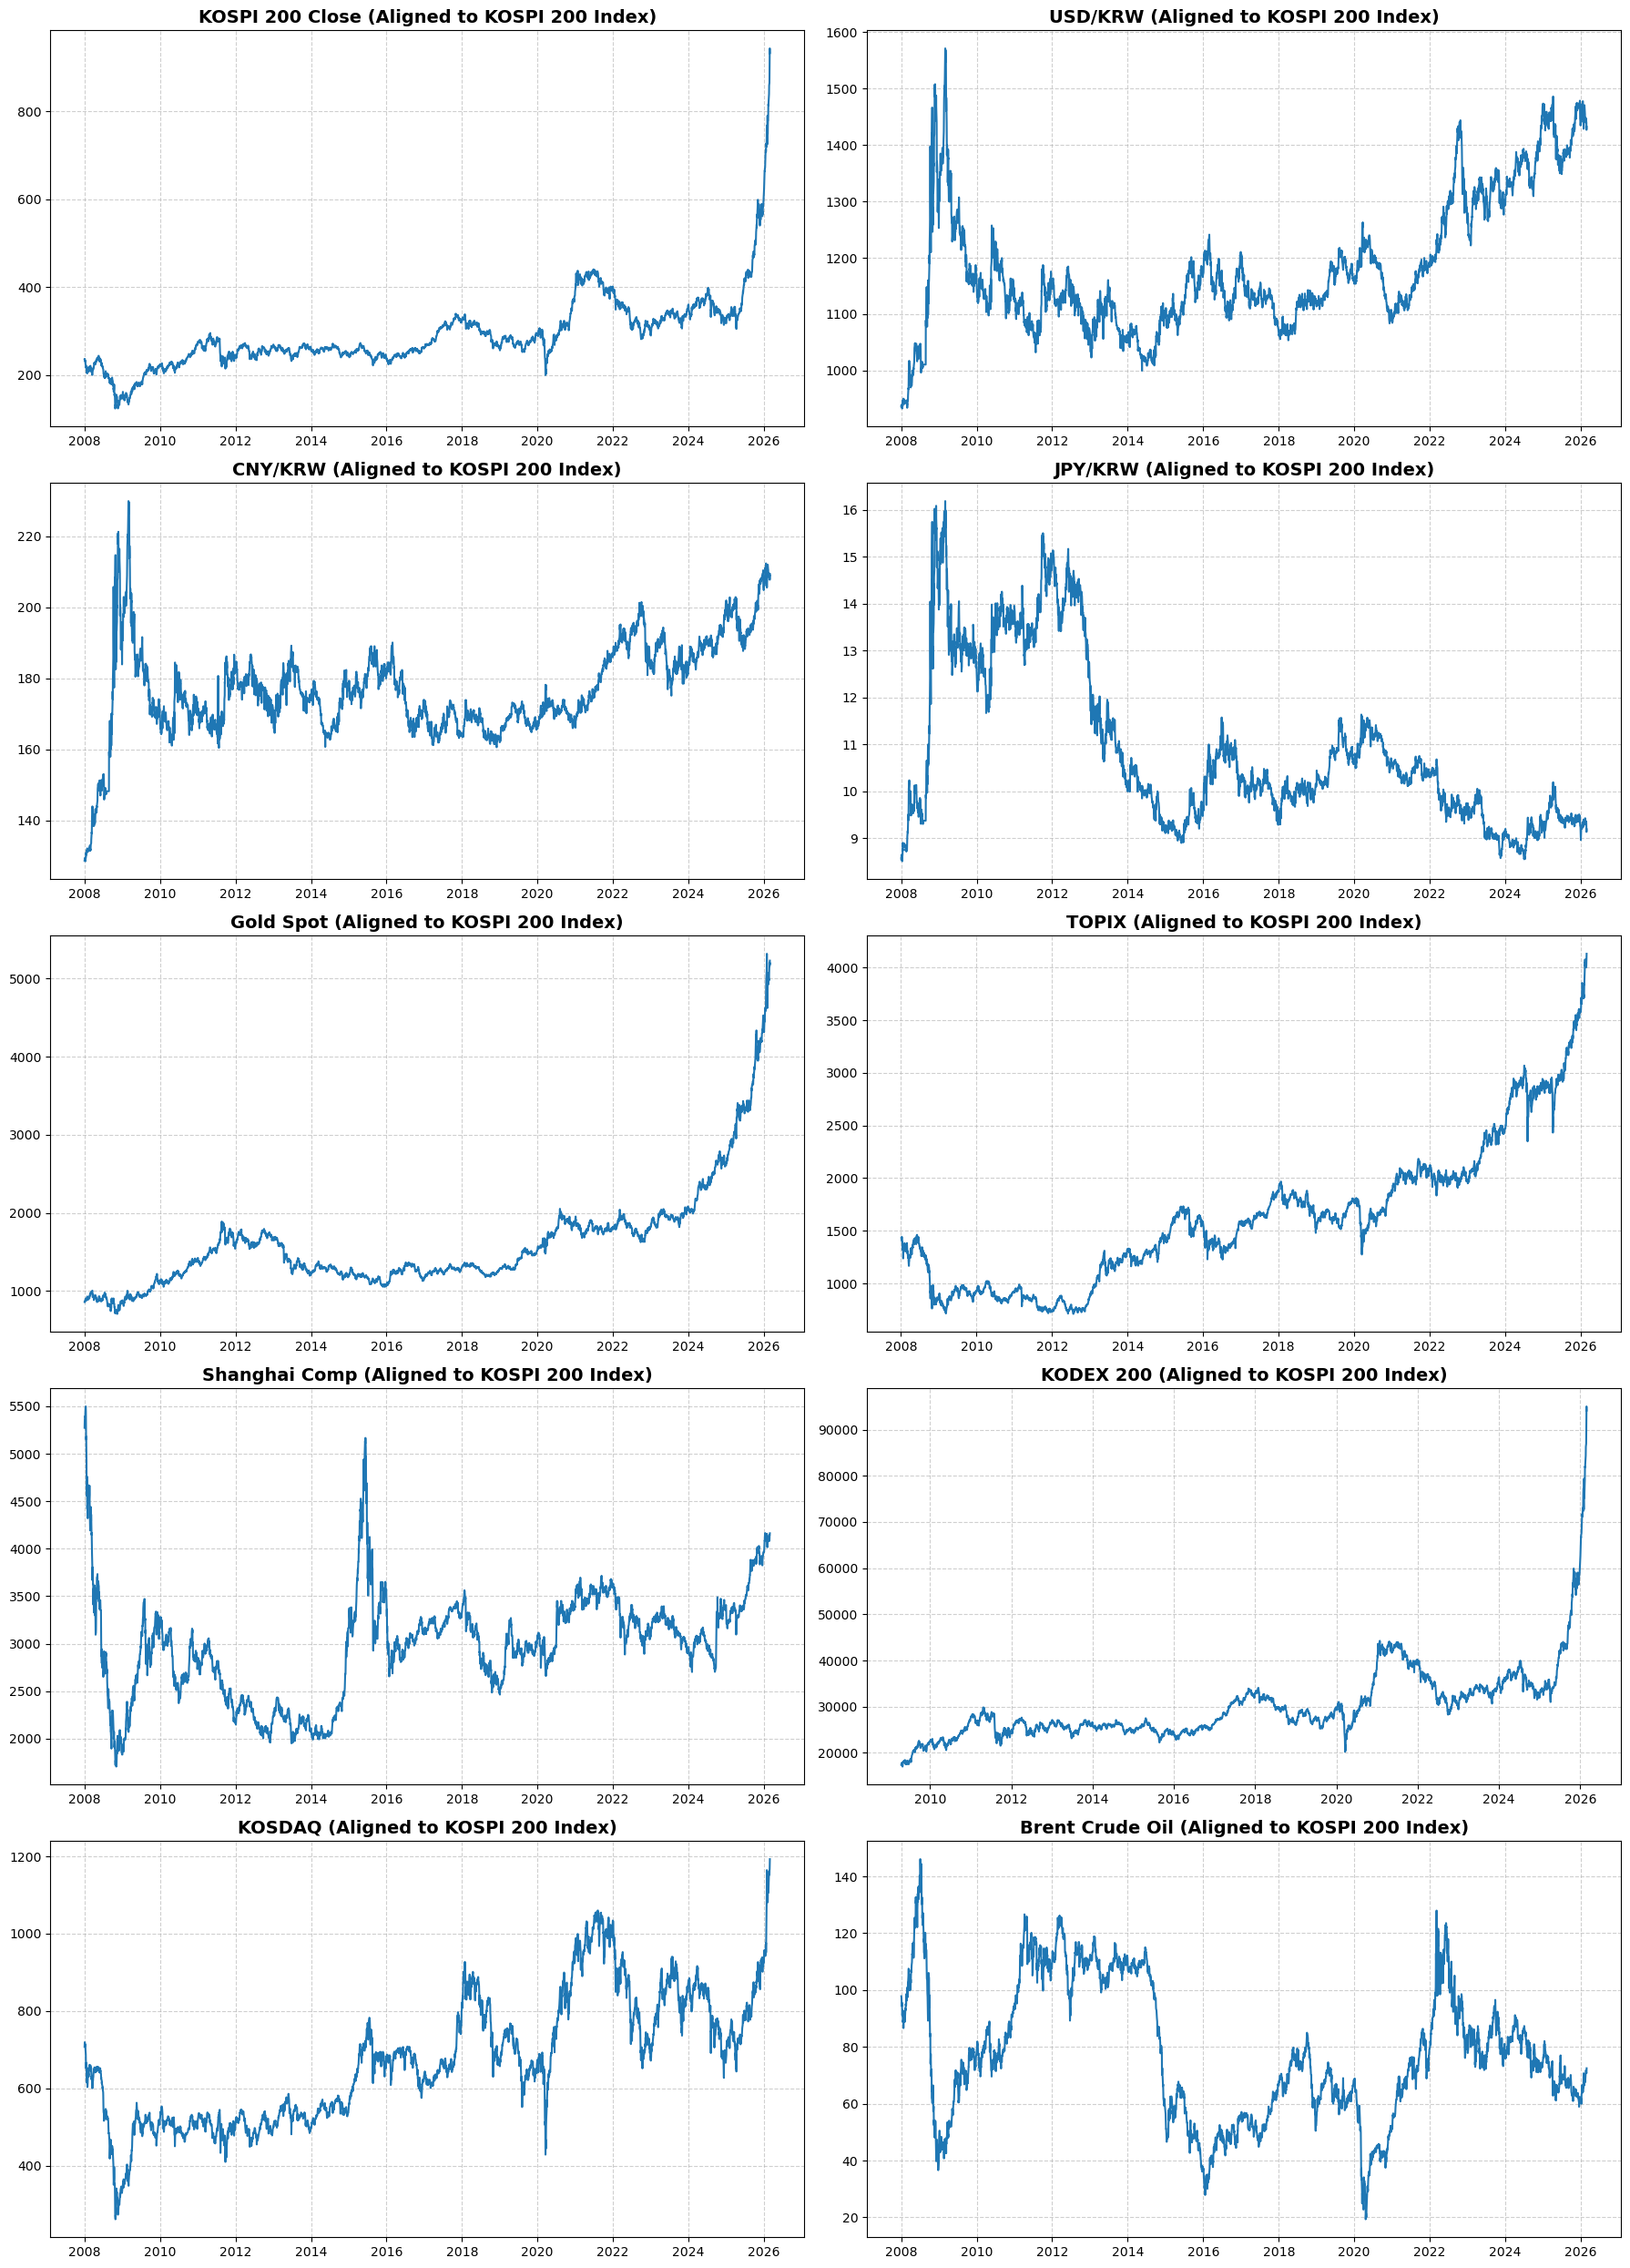

--- KOSPI 200 기준 정렬 검증 ---
전체 데이터 기간: 2008-01-02 ~ 2026-02-27
총 영업일 수: 4429일


,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,JPY/KRW,USD/KRW,NASDAQ,KOSDAQ,KOSPI 200 Close,KOSPI 200 Open,KOSPI 200 High,KOSPI 200 Low,CNY/KRW
Date,,,,,,,,,,,,,,,
2008-01-02,5272.813965,NaN,NaN,97.839996,7.2852,857.000000,8.5750,937.119995,2609.629883,707.119995,235.300003,240.470001,240.649994,235.020004,128.633391
2008-01-03,5319.860840,NaN,NaN,97.599998,7.2629,866.400024,8.5379,935.150024,2602.679932,714.000000,234.669998,232.940002,235.639999,230.860001,128.757114
2008-01-04,5361.574219,NaN,1431.040039,96.790001,7.2630,863.099976,8.6477,939.530029,2504.649902,719.250000,235.770004,234.619995,236.589996,230.410004,129.358396
2008-01-07,5393.342773,NaN,1411.410034,94.389999,7.2578,859.599976,8.5970,939.270020,2499.459961,711.770020,231.000000,229.389999,232.419998,229.089996,129.415251
2008-01-08,5386.530762,NaN,1421.959961,95.540001,7.2535,878.000000,8.6145,938.890015,2440.510010,709.309998,230.339996,231.750000,232.320007,229.190002,129.439583


In [29]:
# 6. 시각화
plot_cols = ['KOSPI 200 Close', 'USD/KRW', 'CNY/KRW', 'JPY/KRW', 'Gold Spot', 'TOPIX', 'Shanghai Comp', 'KODEX 200', 'KOSDAQ', 'Brent Crude Oil']
    
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if col in data.columns:
        series = data[col].dropna()
        axes[i].plot(series.index, series.values, label=col, color='tab:blue')
        axes[i].set_title(f"{col} (Aligned to KOSPI 200 Index)", fontsize=14, fontweight='bold')
        axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 최종 검증
print("--- KOSPI 200 기준 정렬 검증 ---")
print(f"전체 데이터 기간: {data.index.min().date()} ~ {data.index.max().date()}")
print(f"총 영업일 수: {len(data)}일")
display(data.head())

### 결측치 확인

In [30]:


# 1. 정제된 데이터(data)에서의 결측치 확인
final_na_counts = data_2009.isna().sum()

print("--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---")
print(final_na_counts)

print("\n--- 데이터 품질 검증 (시작일 및 샘플) ---")
for col in data_2009.columns:
    first_valid = data_2009[col].first_valid_index()
    last_val = data_2009[col].iloc[-1]
    print(f"{col:15} | 시작일: {first_valid.date()} | 최근값: {last_val:10.2f} | 남은 NaN: {data_2009[col].loc[first_valid:].isna().sum()}")

# 전체 행 수 출력
print(f"\n전체 타임라인 행 수: {len(data_2009)}")

--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---
Shanghai Comp      0
KODEX 200          0
TOPIX              0
Brent Crude Oil    0
USD/CNY            0
Gold Spot          0
JPY/KRW            0
USD/KRW            0
NASDAQ             0
KOSDAQ             0
KOSPI 200 Close    0
KOSPI 200 Open     0
KOSPI 200 High     0
KOSPI 200 Low      0
CNY/KRW            0
dtype: int64

--- 데이터 품질 검증 (시작일 및 샘플) ---
Shanghai Comp   | 시작일: 2009-04-17 | 최근값:    4162.88 | 남은 NaN: 0
KODEX 200       | 시작일: 2009-04-17 | 최근값:   94120.00 | 남은 NaN: 0
TOPIX           | 시작일: 2009-04-17 | 최근값:    4131.00 | 남은 NaN: 0
Brent Crude Oil | 시작일: 2009-04-17 | 최근값:      72.48 | 남은 NaN: 0
USD/CNY         | 시작일: 2009-04-17 | 최근값:       6.84 | 남은 NaN: 0
Gold Spot       | 시작일: 2009-04-17 | 최근값:    5230.50 | 남은 NaN: 0
JPY/KRW         | 시작일: 2009-04-17 | 최근값:       9.19 | 남은 NaN: 0
USD/KRW         | 시작일: 2009-04-17 | 최근값:    1432.32 | 남은 NaN: 0
NASDAQ          | 시작일: 2009-04-17 | 최근값:   22668.21 | 남은 NaN: 0
KOSDAQ          | 시작일: 2009-04